In [ ]:

import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms     

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cuda


In [ ]:
# Paths
train_dir = '/home/subhrajit/Desktop/subhra/dataset/training'
test_dir  = '/home/subhrajit/Desktop/subhra/dataset/testing'

print("Train Path:", train_dir)
print("Test Path:", test_dir)

Train Path: /home/subhrajit/Desktop/subhra/dataset/training
Test Path: /home/subhrajit/Desktop/subhra/dataset/testing


In [3]:
# Convert RGB → Grayscale

for split_path in [train_dir, test_dir]:

    for cls in os.listdir(split_path):
        class_path = os.path.join(split_path, cls)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path)

                if img.mode != "L":
                    img = img.convert("L")
                    img.save(img_path)

            except Exception as e:
                print("Error:", img_path, e)

print("All Images Converted to Grayscale.")

All Images Converted to Grayscale.


In [4]:
# Transforms

train_transform = transforms.Compose([
    transforms.Lambda(lambda x: x.convert("RGB")), 
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Training Transforms Ready.")   

val_test_transform = transforms.Compose([
    transforms.Lambda(lambda x: x.convert("RGB")),  
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Validation & Test Transforms Ready.")

Training Transforms Ready.
Validation & Test Transforms Ready.


In [5]:
# Full training dataset

full_train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

print("Total Training Images:", len(full_train_dataset))

Total Training Images: 5600


In [6]:
# Train-Validation split

from torch.utils.data import random_split

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)

print("Train Size:", len(train_dataset))
print("Validation Size:", len(val_dataset))

Train Size: 4480
Validation Size: 1120


In [7]:
# Apply validation transform

val_dataset.dataset.transform = val_test_transform
print("Validation Transforms Ready.")

Validation Transforms Ready.


In [8]:
# Test dataset

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=val_test_transform
)

print("Test Size:", len(test_dataset))

Test Size: 1600


In [9]:
# Class info

class_names = full_train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of Classes:", num_classes)

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of Classes: 4


In [10]:
# Class Distribution (Train)

from collections import Counter

# Extract labels from full training dataset
labels = [label for _, label in full_train_dataset]

class_counts = Counter(labels)

for idx, count in class_counts.items():
    print(f"{class_names[idx]}: {count}")

glioma: 1400
meningioma: 1400
no_tumor: 1400
pituitary: 1400


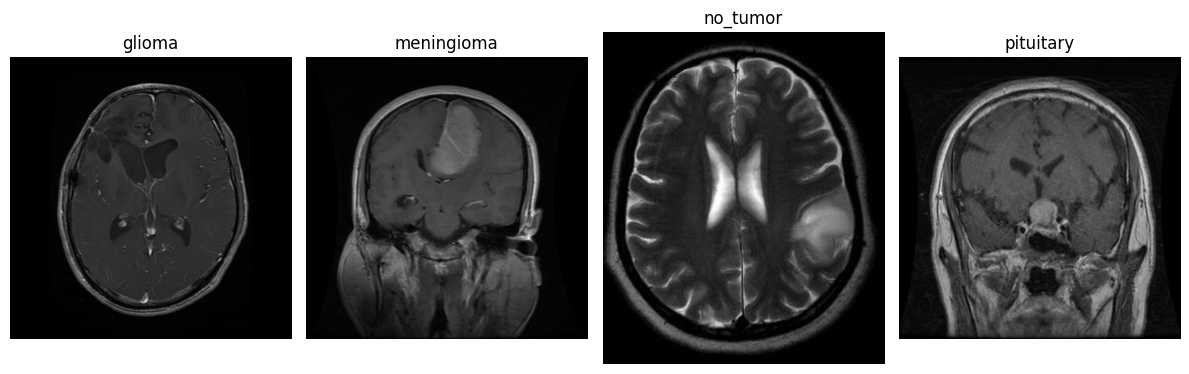

In [11]:
# Visualize each class one image

plt.figure(figsize=(12, 6))

for i, cls in enumerate(class_names):
    class_path = os.path.join(train_dir, cls)
    
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    
    img = Image.open(img_path)

    plt.subplot(1, len(class_names), i+1)
    plt.imshow(img, cmap="gray")  
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

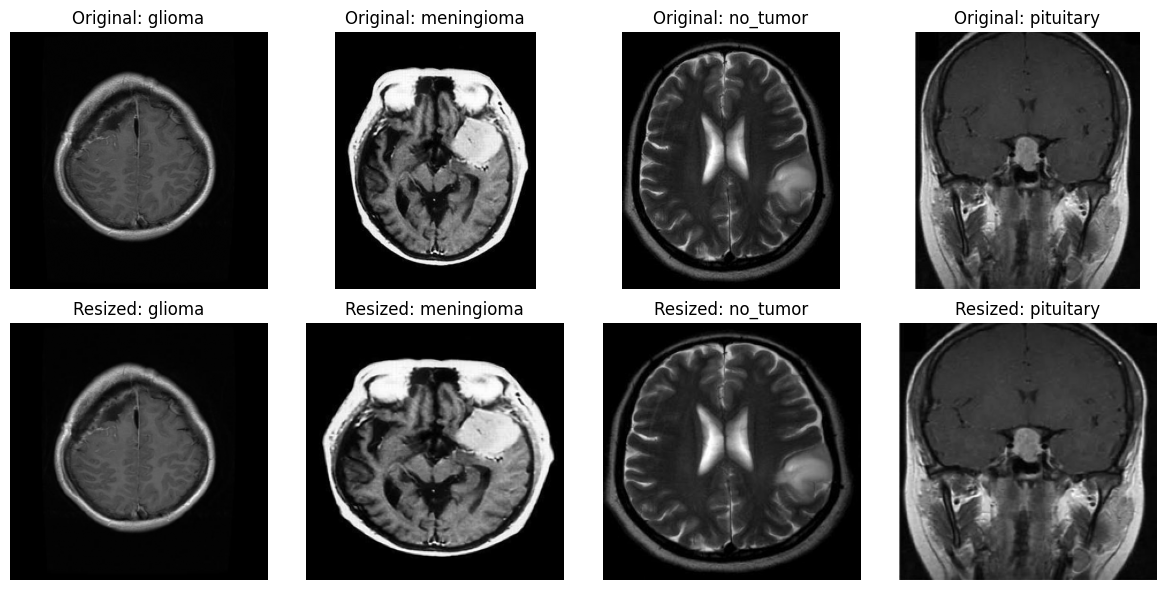

In [12]:
# Resize Preview

import random
import matplotlib.pyplot as plt
from PIL import Image

target_size = (224, 224)

plt.figure(figsize=(12, 6))

for i, cls in enumerate(class_names):  
    class_path = os.path.join(train_dir, cls)
    
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    resized_img = img.resize(target_size)

    # Original
    plt.subplot(2, len(class_names), i + 1)
    plt.imshow(img, cmap="gray") 
    plt.title(f"Original: {cls}")
    plt.axis("off")

    # Resized
    plt.subplot(2, len(class_names), i + 1 + len(class_names))
    plt.imshow(resized_img, cmap="gray") 
    plt.title(f"Resized: {cls}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# DataLoaders

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("DataLoaders Created Successfully.")

DataLoaders Created Successfully.


In [14]:
# COMMON: Train One Epoch

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [15]:
# COMMON: Validate One Epoch

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [16]:
# COMMON: Test Model

def test_model(model, loader, device):
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_preds, all_labels

In [17]:
# COMMON: Metrics

def calculate_metrics(y_true, y_pred, class_names):
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names)

    print(f"Accuracy: {acc:.4f}\n")
    print("Classification Report:\n", report)

    return acc, cm

## CNN Model :

In [18]:
# CNN: Model Load

class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImprovedCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4 
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.6),  # stronger regularization
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Initialize
cnn_model = ImprovedCNN(num_classes).to(device)
print("CNN Model Moved to Device.")

CNN Model Moved to Device.


In [19]:
# CNN: Loss & Optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=1e-5,
    weight_decay=1e-5  # helps reduce overfitting
)

print("Loss Function and Optimizer Set for CNN.")

Loss Function and Optimizer Set for CNN.


In [20]:
# CNN: Training Loop

num_epochs = 50
best_val_loss = float("inf")
best_model_wts = None

patience = 5
counter = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        cnn_model, train_loader, criterion, optimizer, device
    )
    
    val_loss, val_acc = validate_one_epoch(
        cnn_model, val_loader, criterion, device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # Check improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(cnn_model.state_dict())
        counter = 0
        print("Best Model Updated\n")
    else:
        counter += 1
        print(f"No Improvement ({counter}/{patience})\n")

    # Early stopping
    if counter >= patience:
        print("Early Stopping Triggered")
        break

# Load best weights
cnn_model.load_state_dict(best_model_wts)

print("Training Complete. Best Model Loaded.")

Epoch [1/50]
Train Loss: 0.7456 | Train Acc: 0.7007
Val   Loss: 0.5404 | Val   Acc: 0.7857
Best Model Updated

Epoch [2/50]
Train Loss: 0.5250 | Train Acc: 0.8029
Val   Loss: 0.4585 | Val   Acc: 0.8295
Best Model Updated

Epoch [3/50]
Train Loss: 0.4322 | Train Acc: 0.8420
Val   Loss: 0.3894 | Val   Acc: 0.8607
Best Model Updated

Epoch [4/50]
Train Loss: 0.3651 | Train Acc: 0.8699
Val   Loss: 0.3517 | Val   Acc: 0.8804
Best Model Updated

Epoch [5/50]
Train Loss: 0.3171 | Train Acc: 0.8837
Val   Loss: 0.3059 | Val   Acc: 0.8929
Best Model Updated

Epoch [6/50]
Train Loss: 0.2729 | Train Acc: 0.9060
Val   Loss: 0.2751 | Val   Acc: 0.9036
Best Model Updated

Epoch [7/50]
Train Loss: 0.2511 | Train Acc: 0.9138
Val   Loss: 0.2561 | Val   Acc: 0.9045
Best Model Updated

Epoch [8/50]
Train Loss: 0.2139 | Train Acc: 0.9270
Val   Loss: 0.2401 | Val   Acc: 0.9161
Best Model Updated

Epoch [9/50]
Train Loss: 0.1854 | Train Acc: 0.9348
Val   Loss: 0.2332 | Val   Acc: 0.9223
Best Model Updated

E

In [21]:
# CNN: Testing

cnn_preds, cnn_labels = test_model(
    cnn_model, test_loader, device
)

print("CNN Testing Completed.")

CNN Testing Completed.


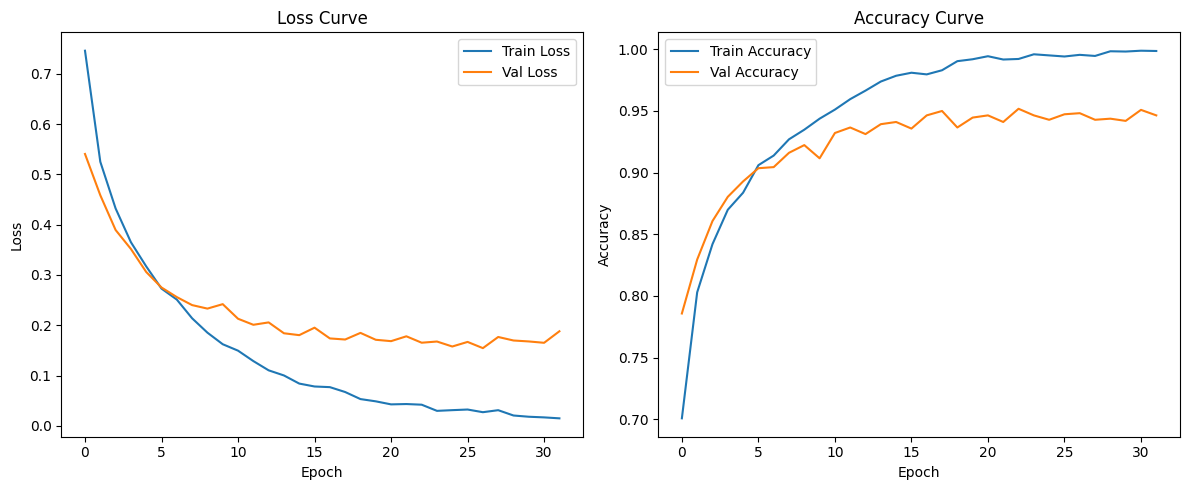

In [22]:
# CNN: Training vs Validation Curves

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
# CNN: Classification Report

cnn_acc, cnn_cm = calculate_metrics(
    cnn_labels, cnn_preds, class_names
)

print("CNN Metrics Computed.")

Accuracy: 0.8912

Classification Report:
               precision    recall  f1-score   support

      glioma       0.93      0.74      0.83       400
  meningioma       0.83      0.90      0.86       400
    no_tumor       0.86      0.99      0.92       400
   pituitary       0.97      0.94      0.95       400

    accuracy                           0.89      1600
   macro avg       0.90      0.89      0.89      1600
weighted avg       0.90      0.89      0.89      1600

CNN Metrics Computed.


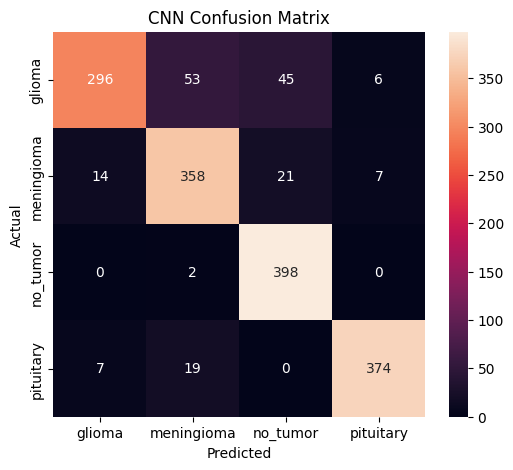

In [24]:
# CNN: Confusion Matrix 

import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

## EfficientNet-B3 Model :

In [25]:
# EfficientNet-B3: Load Model

from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

# Load pretrained model
weights = EfficientNet_B3_Weights.DEFAULT
b3_model = efficientnet_b3(weights=weights)

# Replace classifier
b3_model.classifier[1] = nn.Linear(
    b3_model.classifier[1].in_features,
    num_classes
)

b3_model = b3_model.to(device)

print("EfficientNet-B3 Loaded and Modified.")

EfficientNet-B3 Loaded and Modified.


In [26]:
# EfficientNet-B3: Freeze Backbone

# Freeze all layers
for param in b3_model.features.parameters():
    param.requires_grad = False

print("Backbone frozen (Only Classifier Will Train).")

Backbone frozen (Only Classifier Will Train).


In [27]:
# EfficientNet-B3: Loss & Optimizer 

from collections import Counter

# Get labels from train_dataset
labels = [full_train_dataset[i][1] for i in train_dataset.indices]

class_counts = Counter(labels)
total = sum(class_counts.values())

class_weights = [total / class_counts[i] for i in range(num_classes)]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Loss with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer (classifier only)
optimizer = optim.Adam(
    b3_model.classifier.parameters(),
    lr=1e-4
)

print("Loss (With Class Weights) and Optimizer Set for EfficientNet-B3")

Loss (With Class Weights) and Optimizer Set for EfficientNet-B3


In [28]:
# EfficientNet-B3: Train (Frozen Backbone)

num_epochs = 10
best_val_loss = float("inf")
best_model_wts = None

# For plotting
train_losses_b3 = []
val_losses_b3 = []
train_accs_b3 = []
val_accs_b3 = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        b3_model, train_loader, criterion, optimizer, device
    )
    
    val_loss, val_acc = validate_one_epoch(
        b3_model, val_loader, criterion, device
    )

    train_losses_b3.append(train_loss)
    val_losses_b3.append(val_loss)
    train_accs_b3.append(train_acc)
    val_accs_b3.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(b3_model.state_dict())
        print("Best Model Updated\n")
    else:
        print("No Improvement\n")

# Load best weights
b3_model.load_state_dict(best_model_wts)

print("Feature Extraction Training Complete.")

Epoch [1/10]
Train Loss: 1.2394 | Train Acc: 0.5116
Val   Loss: 1.0716 | Val   Acc: 0.7536
Best Model Updated

Epoch [2/10]
Train Loss: 0.9858 | Train Acc: 0.7522
Val   Loss: 1.2230 | Val   Acc: 0.7866
No Improvement

Epoch [3/10]
Train Loss: 0.8388 | Train Acc: 0.7895
Val   Loss: 0.7604 | Val   Acc: 0.8098
Best Model Updated

Epoch [4/10]
Train Loss: 0.7477 | Train Acc: 0.8007
Val   Loss: 17.0484 | Val   Acc: 0.8205
No Improvement

Epoch [5/10]
Train Loss: 0.6746 | Train Acc: 0.8092
Val   Loss: 0.6241 | Val   Acc: 0.8330
Best Model Updated

Epoch [6/10]
Train Loss: 0.6340 | Train Acc: 0.8172
Val   Loss: 0.8967 | Val   Acc: 0.8259
No Improvement

Epoch [7/10]
Train Loss: 0.5926 | Train Acc: 0.8270
Val   Loss: 0.8439 | Val   Acc: 0.8286
No Improvement

Epoch [8/10]
Train Loss: 0.5635 | Train Acc: 0.8246
Val   Loss: 4.3086 | Val   Acc: 0.8366
No Improvement

Epoch [9/10]
Train Loss: 0.5409 | Train Acc: 0.8348
Val   Loss: 0.5034 | Val   Acc: 0.8393
Best Model Updated

Epoch [10/10]
Train 

In [29]:
# EfficientNet-B3: Fine-Tuning

# Unfreeze last few layers
for param in b3_model.features[-4:].parameters():
    param.requires_grad = True

# Lower learning rate for fine-tuning
optimizer = optim.Adam([
    {"params": b3_model.features.parameters(), "lr": 1e-5},
    {"params": b3_model.classifier.parameters(), "lr": 1e-4}
])

print("Last Layers Unfrozen for Fine-Tuning.")

Last Layers Unfrozen for Fine-Tuning.


In [30]:
# EfficientNet-B3: Train (Fine-Tuning)

num_epochs = 40
best_val_loss = float("inf")
best_model_wts = None

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        b3_model, train_loader, criterion, optimizer, device
    )
    
    val_loss, val_acc = validate_one_epoch(
        b3_model, val_loader, criterion, device
    )

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(b3_model.state_dict())
        print("Best Model Updated\n")
    else:
        print("No Improvement\n")

# Load best weights
b3_model.load_state_dict(best_model_wts)

print("Fine-Tuning Complete.")

Epoch [1/40]
Train Loss: 0.4712 | Train Acc: 0.8469
Val   Loss: 0.7664 | Val   Acc: 0.8732
Best Model Updated

Epoch [2/40]
Train Loss: 0.3622 | Train Acc: 0.8821
Val   Loss: 0.4012 | Val   Acc: 0.8920
Best Model Updated

Epoch [3/40]
Train Loss: 0.3041 | Train Acc: 0.8964
Val   Loss: 0.2603 | Val   Acc: 0.9098
Best Model Updated

Epoch [4/40]
Train Loss: 0.2596 | Train Acc: 0.9076
Val   Loss: 0.2864 | Val   Acc: 0.9089
No Improvement

Epoch [5/40]
Train Loss: 0.2250 | Train Acc: 0.9187
Val   Loss: 0.2034 | Val   Acc: 0.9205
Best Model Updated

Epoch [6/40]
Train Loss: 0.1869 | Train Acc: 0.9379
Val   Loss: 0.1936 | Val   Acc: 0.9357
Best Model Updated

Epoch [7/40]
Train Loss: 0.1639 | Train Acc: 0.9449
Val   Loss: 0.1769 | Val   Acc: 0.9393
Best Model Updated

Epoch [8/40]
Train Loss: 0.1385 | Train Acc: 0.9565
Val   Loss: 3.0056 | Val   Acc: 0.9402
No Improvement

Epoch [9/40]
Train Loss: 0.1238 | Train Acc: 0.9583
Val   Loss: 0.1240 | Val   Acc: 0.9518
Best Model Updated

Epoch [10

In [31]:
# EfficientNet-B3: Testing


b3_preds, b3_labels = test_model(
    b3_model, test_loader, device
)

print("EfficientNet-B3 Testing Completed.")

EfficientNet-B3 Testing Completed.


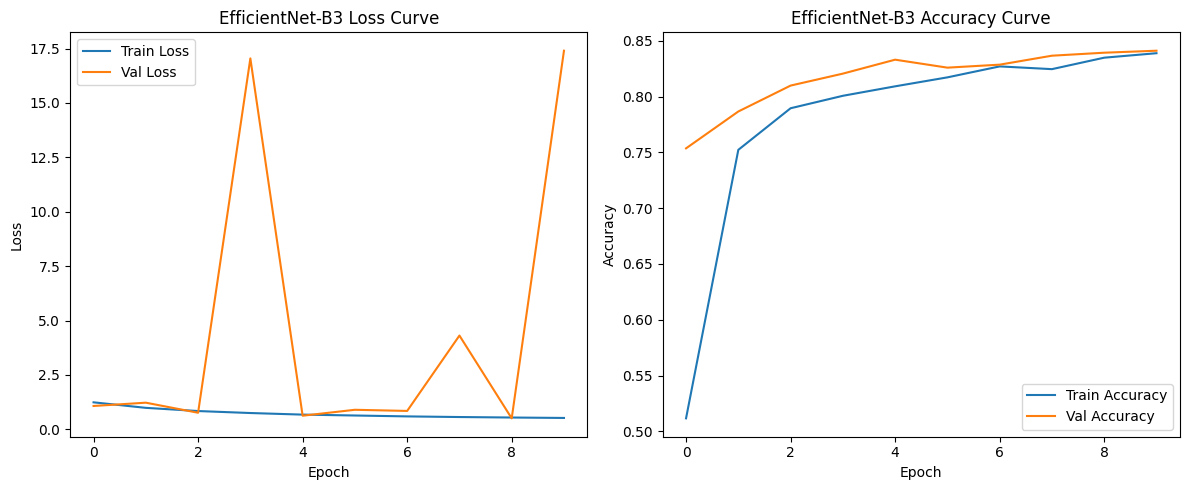

In [32]:
# EfficientNet-B3: Training Curves

plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(train_losses_b3, label="Train Loss")
plt.plot(val_losses_b3, label="Val Loss")
plt.title("EfficientNet-B3 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(train_accs_b3, label="Train Accuracy")
plt.plot(val_accs_b3, label="Val Accuracy")
plt.title("EfficientNet-B3 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
# EfficientNet-B3: Classification Report

b3_acc, b3_cm = calculate_metrics(
    b3_labels, b3_preds, class_names
)

print("EfficientNet-B3 Metrics Computed.")

Accuracy: 0.9387

Classification Report:
               precision    recall  f1-score   support

      glioma       0.98      0.81      0.88       400
  meningioma       0.89      0.97      0.93       400
    no_tumor       0.92      1.00      0.95       400
   pituitary       0.98      0.98      0.98       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600

EfficientNet-B3 Metrics Computed.


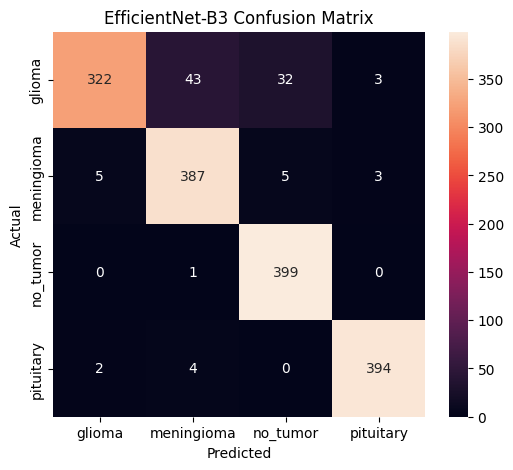

In [34]:
# EfficientNet-B3: Confusion Matrix

import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(
    b3_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNet-B3 Confusion Matrix")
plt.show()

## EfficientNet V2-S Model : 

In [35]:
# EfficientNet-V2-S: Load Model

from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

# Load pretrained
weights = EfficientNet_V2_S_Weights.DEFAULT
v2_model = efficientnet_v2_s(weights=weights)

# Replace classifier
v2_model.classifier[1] = nn.Linear(
    v2_model.classifier[1].in_features,
    num_classes
)

v2_model = v2_model.to(device)

print("EfficientNet-V2-S Loaded and Modified.")

EfficientNet-V2-S Loaded and Modified.


In [36]:
# EfficientNet-V2-S: Freeze Backbone

for param in v2_model.features.parameters():
    param.requires_grad = False

print("Backbone Frozen (Only Classifier Will Train).")

Backbone Frozen (Only Classifier Will Train).


In [37]:
# EfficientNet-V2-S: Loss & Optimizer

from collections import Counter

# Compute class weights 
labels = [full_train_dataset[i][1] for i in train_dataset.indices]

class_counts = Counter(labels)
total = sum(class_counts.values())

class_weights = [total / class_counts[i] for i in range(num_classes)]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer 
optimizer = optim.Adam(
    v2_model.classifier.parameters(),
    lr=1e-4
)

print("Loss (With Class Weights) and Optimizer Set for V2-S.")

Loss (With Class Weights) and Optimizer Set for V2-S.


In [38]:
# EfficientNet-V2-S: Train (Frozen Backbone)

num_epochs = 10
best_val_loss = float("inf")
best_model_wts = None

# For plotting
train_losses_v2 = []
val_losses_v2 = []
train_accs_v2 = []
val_accs_v2 = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        v2_model, train_loader, criterion, optimizer, device
    )
    
    val_loss, val_acc = validate_one_epoch(
        v2_model, val_loader, criterion, device
    )

    train_losses_v2.append(train_loss)
    val_losses_v2.append(val_loss)
    train_accs_v2.append(train_acc)
    val_accs_v2.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.6f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.6f} | Val   Acc: {val_acc:.4f}")

    # Save best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(v2_model.state_dict())
        print("Best Model Updated\n")
    else:
        print("No Improvement\n")

# Load best weights
v2_model.load_state_dict(best_model_wts)

print("Feature Extraction Complete.")

Epoch [1/10]
Train Loss: 1.251450 | Train Acc: 0.4946
Val   Loss: 1.089628 | Val   Acc: 0.7509
Best Model Updated

Epoch [2/10]
Train Loss: 1.013885 | Train Acc: 0.7268
Val   Loss: 0.898810 | Val   Acc: 0.7911
Best Model Updated

Epoch [3/10]
Train Loss: 0.871497 | Train Acc: 0.7694
Val   Loss: 0.773815 | Val   Acc: 0.8170
Best Model Updated

Epoch [4/10]
Train Loss: 0.772455 | Train Acc: 0.7915
Val   Loss: 0.700451 | Val   Acc: 0.8143
Best Model Updated

Epoch [5/10]
Train Loss: 0.713108 | Train Acc: 0.7882
Val   Loss: 0.640513 | Val   Acc: 0.8295
Best Model Updated

Epoch [6/10]
Train Loss: 0.661222 | Train Acc: 0.8092
Val   Loss: 0.603294 | Val   Acc: 0.8286
Best Model Updated

Epoch [7/10]
Train Loss: 0.634969 | Train Acc: 0.8040
Val   Loss: 0.571133 | Val   Acc: 0.8295
Best Model Updated

Epoch [8/10]
Train Loss: 0.602666 | Train Acc: 0.8143
Val   Loss: 0.540334 | Val   Acc: 0.8402
Best Model Updated

Epoch [9/10]
Train Loss: 0.581938 | Train Acc: 0.8174
Val   Loss: 0.521580 | Val

In [39]:
# EfficientNet-V2-S: Fine-Tuning Setup

# Unfreeze all feature layers
for param in v2_model.features.parameters():
    param.requires_grad = True

# Freeze early layers 
for param in v2_model.features[:4].parameters():
    param.requires_grad = False

# Differential learning rate
optimizer = optim.Adam([
    {"params": v2_model.features.parameters(), "lr": 5e-6},   
    {"params": v2_model.classifier.parameters(), "lr": 1e-4}  
])

print("Partial Unfreezing & Differential LR Set for V2-S.")

Partial Unfreezing & Differential LR Set for V2-S.


In [40]:
# EfficientNet-V2-S: Train (Fine-Tuning)

num_epochs = 35
best_val_loss = float("inf")
best_model_wts = None

# Early stopping
patience = 5
counter = 0

for epoch in range(num_epochs):
    v2_model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        
        outputs = v2_model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        # Gradient clipping 
        torch.nn.utils.clip_grad_norm_(v2_model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item() * images.size(0)
        
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    val_loss, val_acc = validate_one_epoch(
        v2_model, val_loader, criterion, device
    )

    train_losses_v2.append(train_loss)
    val_losses_v2.append(val_loss)
    train_accs_v2.append(train_acc)
    val_accs_v2.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.6f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.6f} | Val   Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(v2_model.state_dict())
        counter = 0
        print("Best Model Updated\n")
    else:
        counter += 1
        print(f"No Improvement ({counter}/{patience})\n")

    # Early stopping
    if counter >= patience:
        print("Early Stopping Triggered.")
        break

# Load best weights
v2_model.load_state_dict(best_model_wts)

print("Fine-Tuning Complete.")

Epoch [1/35]
Train Loss: 0.454275 | Train Acc: 0.8551
Val   Loss: 0.337439 | Val   Acc: 0.8804
Best Model Updated

Epoch [2/35]
Train Loss: 0.326495 | Train Acc: 0.8879
Val   Loss: 0.264380 | Val   Acc: 0.9000
Best Model Updated

Epoch [3/35]
Train Loss: 0.257238 | Train Acc: 0.9129
Val   Loss: 0.215199 | Val   Acc: 0.9170
Best Model Updated

Epoch [4/35]
Train Loss: 0.203481 | Train Acc: 0.9324
Val   Loss: 0.178963 | Val   Acc: 0.9250
Best Model Updated

Epoch [5/35]
Train Loss: 0.167112 | Train Acc: 0.9415
Val   Loss: 0.157785 | Val   Acc: 0.9330
Best Model Updated

Epoch [6/35]
Train Loss: 0.124373 | Train Acc: 0.9558
Val   Loss: 0.140147 | Val   Acc: 0.9464
Best Model Updated

Epoch [7/35]
Train Loss: 0.113322 | Train Acc: 0.9592
Val   Loss: 0.128664 | Val   Acc: 0.9482
Best Model Updated

Epoch [8/35]
Train Loss: 0.080198 | Train Acc: 0.9759
Val   Loss: 0.111594 | Val   Acc: 0.9545
Best Model Updated

Epoch [9/35]
Train Loss: 0.066698 | Train Acc: 0.9777
Val   Loss: 0.096799 | Val

In [41]:
# EfficientNet-V2-S: Testing

v2_preds, v2_labels = test_model(
    v2_model, test_loader, device
)

print("EfficientNet-V2-S Testing Completed.")

EfficientNet-V2-S Testing Completed.


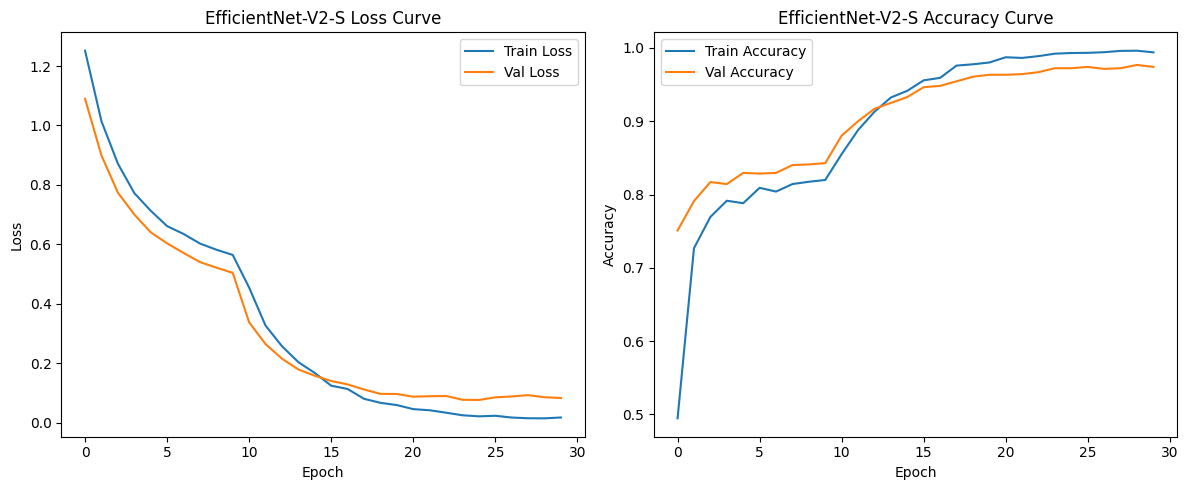

In [42]:
# EfficientNet-V2-S: Training Curves

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses_v2, label="Train Loss")
plt.plot(val_losses_v2, label="Val Loss")
plt.title("EfficientNet-V2-S Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accs_v2, label="Train Accuracy")
plt.plot(val_accs_v2, label="Val Accuracy")
plt.title("EfficientNet-V2-S Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [43]:
# EfficientNet-V2-S: Classification Report

v2_acc, v2_cm = calculate_metrics(
    v2_labels, v2_preds, class_names
)

print("EfficientNet-V2-S Metrics Computed.")

Accuracy: 0.9406

Classification Report:
               precision    recall  f1-score   support

      glioma       0.99      0.82      0.89       400
  meningioma       0.90      0.96      0.93       400
    no_tumor       0.92      1.00      0.96       400
   pituitary       0.97      0.99      0.98       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600

EfficientNet-V2-S Metrics Computed.


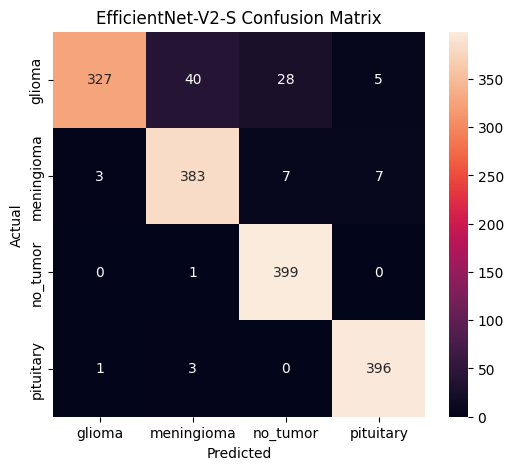

In [44]:
# EfficientNet-V2-S: Confusion Matrix

import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(
    v2_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNet-V2-S Confusion Matrix")
plt.show()

## Final Evaluation & Comparision :

CNN: 0.8912
EfficientNet-B3: 0.9387
EfficientNet-V2-S: 0.9406


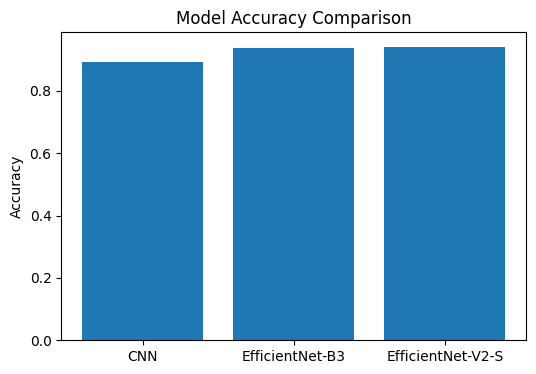

In [45]:
# Accuracy Comparison

models = ["CNN", "EfficientNet-B3", "EfficientNet-V2-S"]
accuracies = [cnn_acc, b3_acc, v2_acc]

for m, acc in zip(models, accuracies):
    print(f"{m}: {acc:.4f}")

# Bar plot
plt.figure(figsize=(6, 4))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

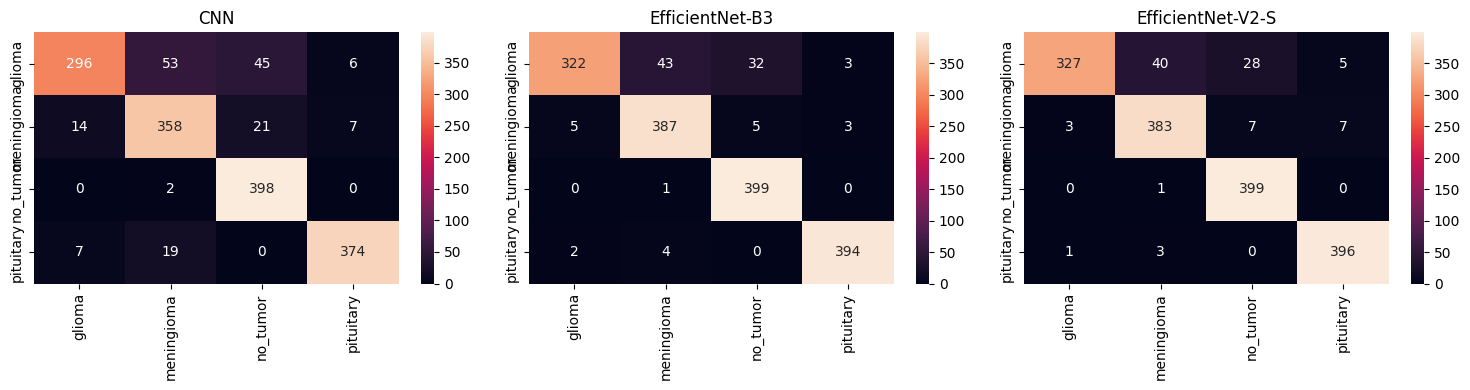

In [46]:

# Confusion Matrix Comparison

import seaborn as sns

plt.figure(figsize=(15, 4))

# CNN
plt.subplot(1, 3, 1)
sns.heatmap(cnn_cm, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names)
plt.title("CNN")

# B3
plt.subplot(1, 3, 2)
sns.heatmap(b3_cm, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names)
plt.title("EfficientNet-B3")

# V2-S
plt.subplot(1, 3, 3)
sns.heatmap(v2_cm, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names)
plt.title("EfficientNet-V2-S")

plt.tight_layout()
plt.show()